# **EfficientNet Pre-trained Binary Model with Transformed Input**

In this notebook we test a pre-trained EfficientNet model to predict Animal vs Non-animal. <br>
For this, transformed/pre-processed images were used, which were generated with the help of the notebook `cleaner_routine.ipynb`. <br>

If you have ran any other model before, do not forget to reset the `input_image_directory` by running 'reset input' in the terminal.

## Libraries

In [ ]:
import os
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

In [1]:
# Libraries
import pandas as pd

from deep.constants import ROOT, METADATA_FILE, SEEDS, SCORES
from deep.modelling.model_runs import run_binary_model
from deep.modelling.model_specifications import efficient_net

2025-04-30 10:34:24.676658: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-30 10:34:24.687839: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-30 10:34:24.701611: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-30 10:34:24.705698: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-30 10:34:24.716539: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# Setting options
pd.set_option('display.max_rows', None)

## Data Loading

In [3]:
# Load the metadata
data = pd.read_csv(METADATA_FILE)

# Drop unnecessary columns for this problem
data.drop(columns=['phylum', 'family'], inplace=True)

## Data Preprocessing

In [4]:
# Define seeds and path
binary_baseline_path = f"{SCORES}/binary_scores.json"

### Clean Images

In [ ]:
# Create transformed images
notebook_path = f'"{ROOT}/notebooks/preprocess_routine/cleaner_routine.ipynb"'
%run $notebook_path

### Resize Images

In [ ]:
# Resize images
notebook_path = f'"{ROOT}/notebooks/preprocess_routine/resize_routine.ipynb"'
%run $notebook_path

## Data Modelling

### Raw Model

In this section we test which loss function yields the best results

#### Binary CrossEntropy

I0000 00:00:1745988638.626451   33256 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745988638.792271   33256 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745988638.792487   33256 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745988638.793576   33256 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Loaded baseline score: 0.9301187992095947
Found 7013 validated image filenames belonging to 2 classes.
Found 1239 validated image filenames belonging to 2 classes.
Found 2068 validated image filenames belonging to 2 classes.


/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 1135 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(
/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 200 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(
/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 329 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(


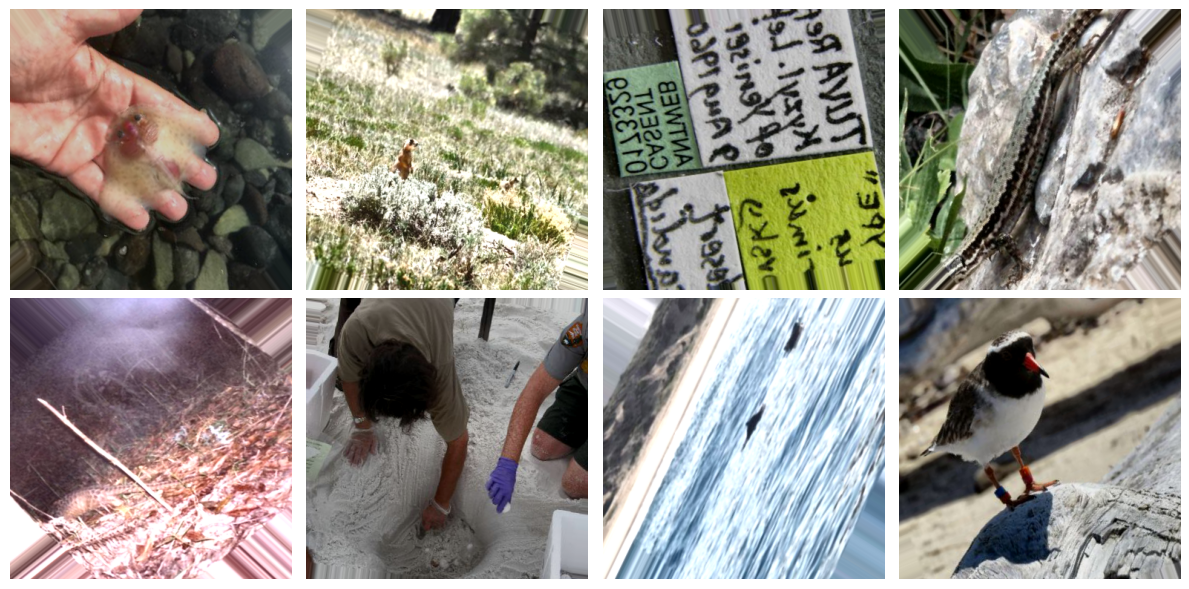

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1745988659.446147   33376 service.cc:146] XLA service 0x751864014bb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745988659.446170   33376 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce MX350, Compute Capability 6.1
2025-04-30 05:51:00.109762: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-30 05:51:02.370241: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90100
2025-04-30 05:51:08.020533: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.34GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-04-30 05:51:11.156043: E external/local_xla/xla/service/slow_operation_alarm.cc:65] 

 24/255 ━━━━━━━━━━━━━━━━━━━━ 3:48 991ms/step - accuracy: 0.9205 - auc: 0.5475 - loss: 0.3397 - precision: 0.9389 - recall: 0.9791

2025-04-30 05:52:12.232292: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.77GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


220/255 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9266 - auc: 0.5047 - loss: 0.2964 - precision: 0.9298 - recall: 0.9964

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


255/255 ━━━━━━━━━━━━━━━━━━━━ 410s 1s/step - accuracy: 0.9265 - auc: 0.5055 - loss: 0.2941 - precision: 0.9294 - recall: 0.9968 - val_accuracy: 0.9290 - val_auc: 0.5000 - val_loss: 0.4686 - val_precision: 0.9290 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 336s 1s/step - accuracy: 0.9245 - auc: 0.5243 - loss: 0.2695 - precision: 0.9245 - recall: 1.0000 - val_accuracy: 0.9290 - val_auc: 0.4961 - val_loss: 0.2758 - val_precision: 0.9290 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 342s 1s/step - accuracy: 0.9245 - auc: 0.5300 - loss: 0.2694 - precision: 0.9245 - recall: 1.0000 - val_accuracy: 0.9290 - val_auc: 0.5331 - val_loss: 0.2719 - val_precision: 0.9290 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 351s 1s/step - accuracy: 0.9245 - auc: 0.5403 - loss: 0.2679 - precision: 0.9245 - recall: 1.0000 - val_accuracy: 0.9290 - val_auc: 0.6209 - val_loss: 0.2601 - val_precis

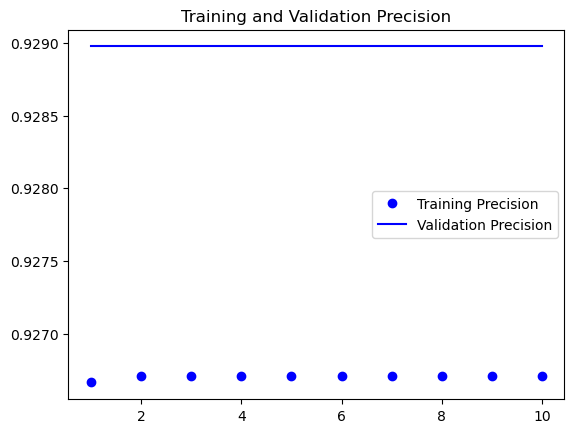

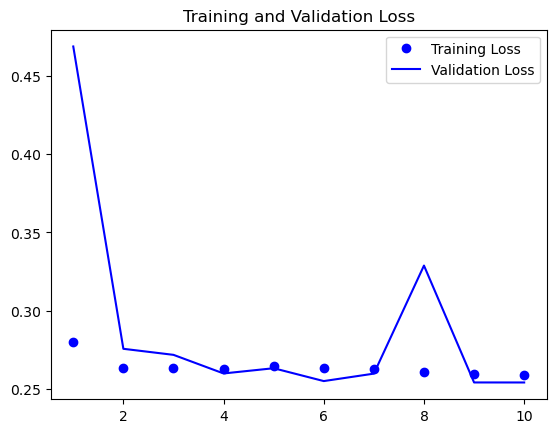

Current model not better than baseline


In [5]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net(
        regularizer=False
        ,dropout=False
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='transformed'
    ,model_name='efficientnetb4'
)

#### Focal Loss

Loaded baseline score: 0.9301187992095947
Found 7013 validated image filenames belonging to 2 classes.
Found 1239 validated image filenames belonging to 2 classes.
Found 2068 validated image filenames belonging to 2 classes.


/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 1135 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(
/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 200 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(
/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 329 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(


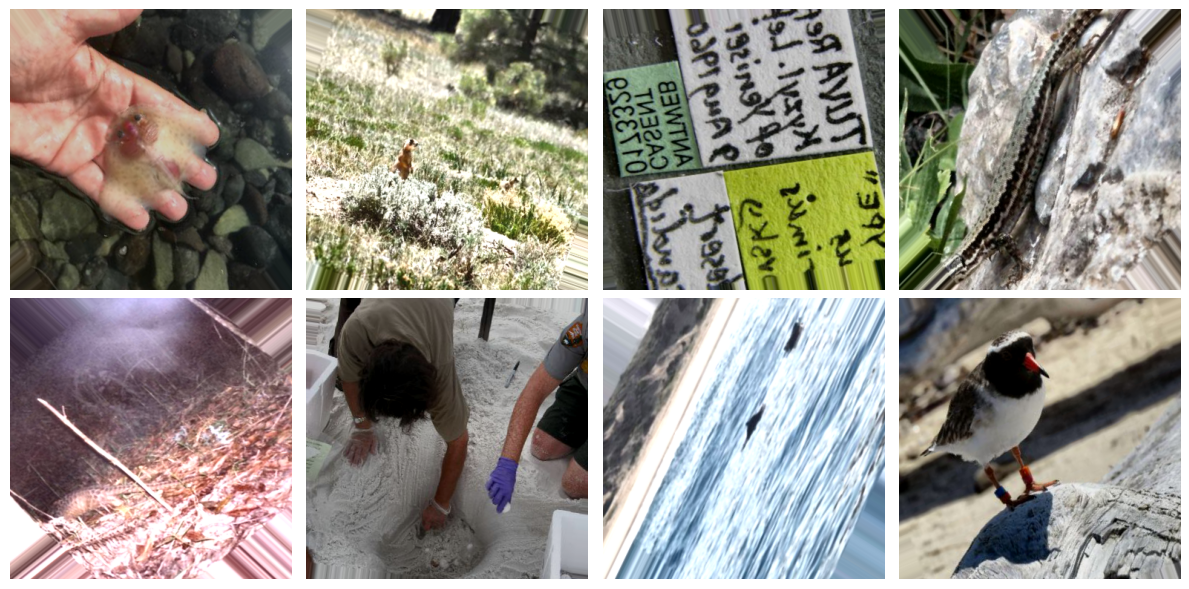

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
220/255 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.8576 - auc_1: 0.4904 - loss: 0.0106 - precision: 0.9279 - recall: 0.9179

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


255/255 ━━━━━━━━━━━━━━━━━━━━ 435s 2s/step - accuracy: 0.8625 - auc_1: 0.4896 - loss: 0.0102 - precision: 0.9278 - recall: 0.9238 - val_accuracy: 0.0726 - val_auc_1: 0.4117 - val_loss: 0.0084 - val_precision: 0.7500 - val_recall: 0.0026 - learning_rate: 0.0010
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 365s 1s/step - accuracy: 0.9062 - auc_1: 0.4951 - loss: 0.0063 - precision: 0.9290 - recall: 0.9735 - val_accuracy: 0.0710 - val_auc_1: 0.4750 - val_loss: 0.0119 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 373s 1s/step - accuracy: 0.9107 - auc_1: 0.4971 - loss: 0.0063 - precision: 0.9282 - recall: 0.9795 - val_accuracy: 0.9290 - val_auc_1: 0.5277 - val_loss: 0.0060 - val_precision: 0.9290 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 379s 1s/step - accuracy: 0.9181 - auc_1: 0.4634 - loss: 0.0062 - precision: 0.9302 - recall: 0.9858 - val_accuracy: 0.9290 - val_auc_1: 0.4982 - val_l

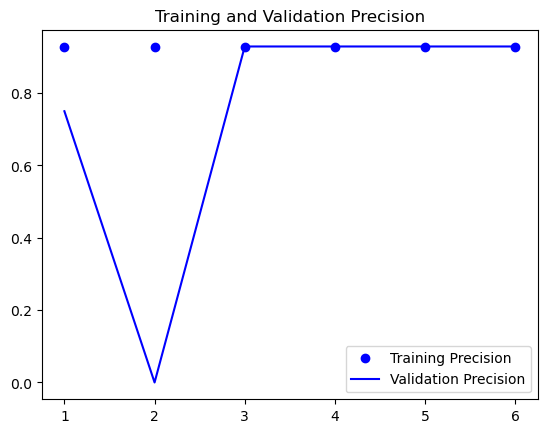

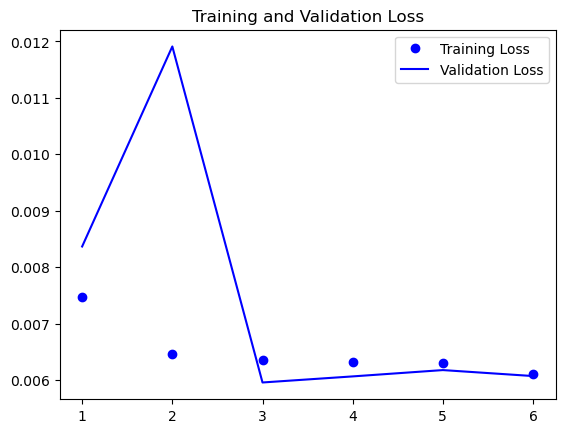

Current model not better than baseline


In [6]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net(
        regularizer=False
        ,dropout=False
    )
    ,loss='focal'
    ,epochs=10
    ,type='transformed'
    ,model_name='efficientnetb4'
)

The binary crossentropy loss function performed better and so this is the loss function we will be using from now on.

### Model with Regularization

In this section we add L2 regularization to our model and test if it improves the model

Loaded baseline score: 0.9301187992095947
Found 7013 validated image filenames belonging to 2 classes.
Found 1239 validated image filenames belonging to 2 classes.
Found 2068 validated image filenames belonging to 2 classes.


/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 1135 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(
/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 200 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(
/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 329 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(


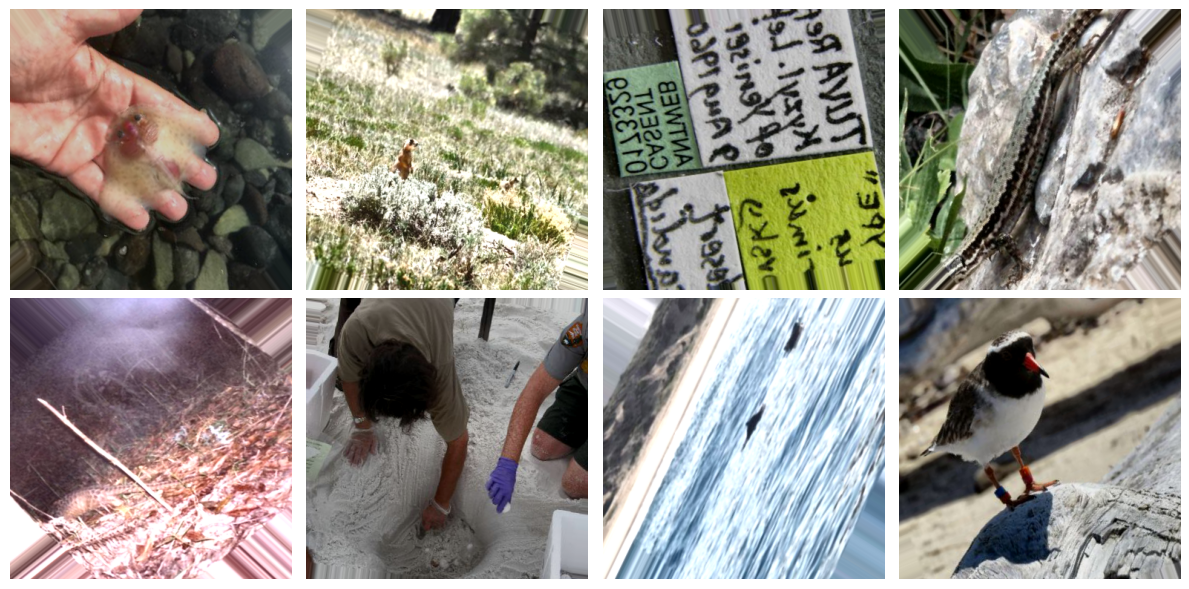

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
220/255 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9061 - auc_3: 0.5039 - loss: 0.4881 - precision: 0.9251 - recall: 0.9771

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


255/255 ━━━━━━━━━━━━━━━━━━━━ 371s 1s/step - accuracy: 0.9085 - auc_3: 0.5062 - loss: 0.4739 - precision: 0.9253 - recall: 0.9797 - val_accuracy: 0.9290 - val_auc_3: 0.5100 - val_loss: 0.3909 - val_precision: 0.9290 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 341s 1s/step - accuracy: 0.9284 - auc_3: 0.5397 - loss: 0.2752 - precision: 0.9284 - recall: 1.0000 - val_accuracy: 0.9290 - val_auc_3: 0.5000 - val_loss: 0.7388 - val_precision: 0.9290 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
220/255 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.9315 - auc_3: 0.5570 - loss: 0.2533 - precision: 0.9315 - recall: 1.0000
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
255/255 ━━━━━━━━━━━━━━━━━━━━ 346s 1s/step - accuracy: 0.9308 - auc_3: 0.5546 - loss: 0.2552 - precision: 0.9308 - recall: 1.0000 - val_accuracy: 0.9290 - val_auc_3: 0.5000 - val_loss: 0.4687 - val_precision: 0.9290 - val_recall: 1.0000 - learning_rate: 0

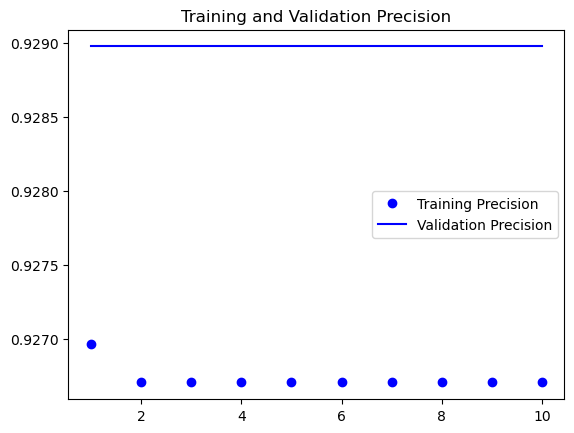

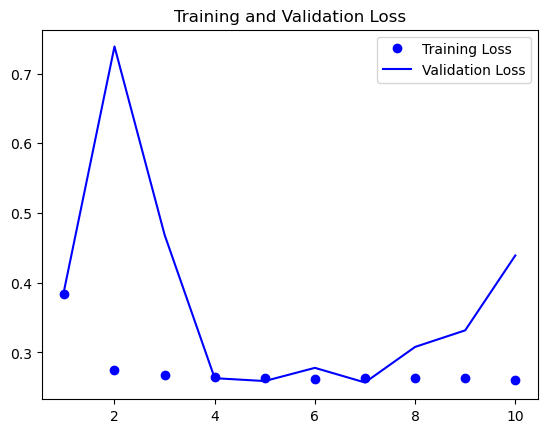

Current model not better than baseline


In [8]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net(
        regularizer=True
        ,dropout=False
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='transformed'
    ,model_name='efficientnetb4'
)

Regularization did not improve the model.

### Model with Dropout

In this section we add a dropout layer to the model and test if it improves the results.

I0000 00:00:1746005681.141397   45541 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1746005681.178361   45541 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1746005681.178572   45541 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1746005681.179737   45541 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Loaded baseline score: 0.9301187992095947
Found 7013 validated image filenames belonging to 2 classes.
Found 1239 validated image filenames belonging to 2 classes.
Found 2068 validated image filenames belonging to 2 classes.


/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 1135 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(
/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 200 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(
/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 329 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(


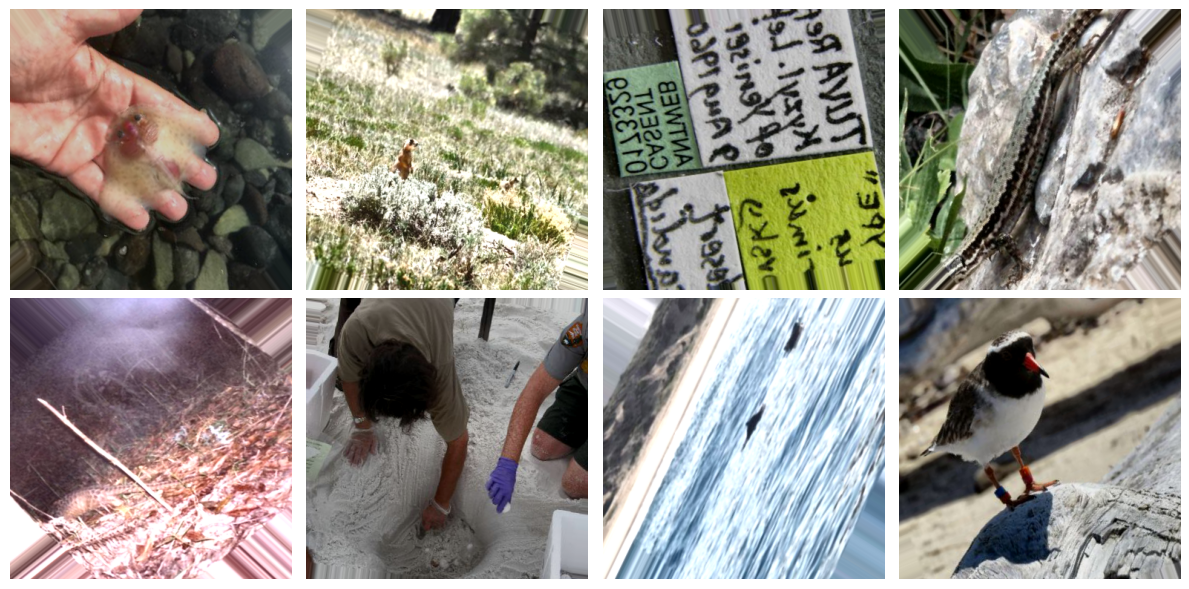

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1746005702.436795   45673 service.cc:146] XLA service 0x7f26e40043d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746005702.436817   45673 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce MX350, Compute Capability 6.1
2025-04-30 10:35:03.065013: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-30 10:35:05.252159: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90100
2025-04-30 10:35:10.874070: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.34GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-04-30 10:35:14.011144: E external/local_xla/xla/service/slow_operation_alarm.cc:65] 

  3/255 ━━━━━━━━━━━━━━━━━━━━ 3:56 937ms/step - accuracy: 0.2656 - auc: 0.4044 - loss: 1.6570 - precision: 0.8647 - recall: 0.2415

2025-04-30 10:35:53.976660: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.77GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


220/255 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.8588 - auc: 0.5162 - loss: 0.4252 - precision: 0.9204 - recall: 0.9256

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


255/255 ━━━━━━━━━━━━━━━━━━━━ 406s 1s/step - accuracy: 0.8663 - auc: 0.5174 - loss: 0.4095 - precision: 0.9213 - recall: 0.9336 - val_accuracy: 0.9290 - val_auc: 0.5664 - val_loss: 0.4944 - val_precision: 0.9290 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 332s 1s/step - accuracy: 0.9275 - auc: 0.5335 - loss: 0.2682 - precision: 0.9275 - recall: 1.0000 - val_accuracy: 0.9290 - val_auc: 0.5585 - val_loss: 0.2803 - val_precision: 0.9290 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 341s 1s/step - accuracy: 0.9246 - auc: 0.5197 - loss: 0.2743 - precision: 0.9246 - recall: 1.0000 - val_accuracy: 0.9290 - val_auc: 0.5778 - val_loss: 0.3281 - val_precision: 0.9290 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
220/255 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.9265 - auc: 0.5038 - loss: 0.2698 - precision: 0.9265 - recall: 1.0000
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.000500000023748725

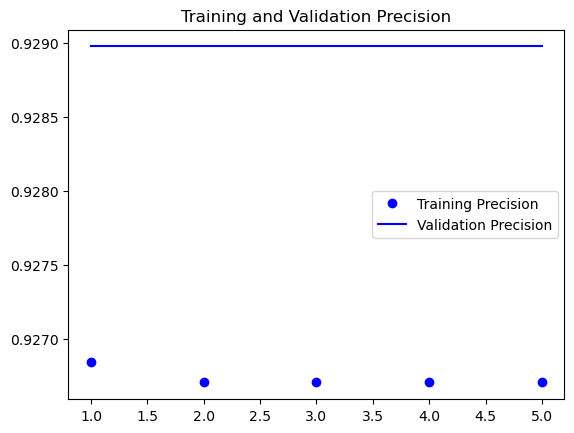

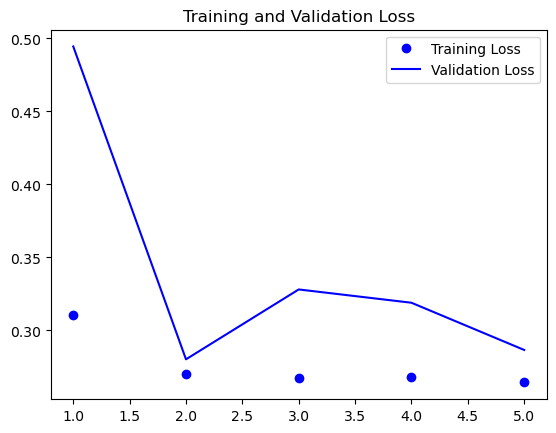

Current model not better than baseline


In [5]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net(
        regularizer=False
        ,dropout=True
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='transformed'
    ,model_name='efficientnetb4'
)

The dropout layer did not improve the model.

Now, we will attempt to fix the class imbalance based on the transformed images and recheck the model.